<a href="https://colab.research.google.com/github/aridhapebriani/ADW/blob/main/Tugas_Minggu_5_Kelompok_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Kelompok 2

Kelompok 2:

- Ain Fitri Basri (M0501251051)

- Alma Alifia Halimatunnisa (M0501251004)

- Aridha Pebriani Kusmiran (M0501251049)

In [174]:
!pip install rpy2

In [175]:
!pip install PythonTsa

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from scipy.stats import boxcox,  boxcox_llf

import warnings
warnings.filterwarnings("ignore")

# 1. Simulasikan deret MA (1) deret parameter $θ=0.6$ dan panjang amatan 120.

In [177]:
from statsmodels.tsa.arima_process import ArmaProcess

# Seed
np.random.seed(104)

# Parameter MA(1)
theta = -0.6

# MA(1): [1, theta]
ma_ma1 = np.array([1, theta])
ar_ma1 = np.array([1])

# Simulasi data
data_ma1 = ArmaProcess(ar_ma1, ma_ma1).generate_sample(nsample=120)

# Tampilkan data
print(data_ma1)

[-0.41821323 -0.29100568 -0.28274973  1.29231257  0.00587208 -0.9869808
  2.56213684 -1.50681106 -0.194768    0.25690438  0.95618376 -1.13139792
 -1.21318342  0.57821538  0.91715774 -0.56271846  0.58725089 -0.952419
  0.74712066 -1.01316148  1.48900758  0.68209645 -2.38923945  0.48367518
 -0.35509961 -0.26170753 -0.57590181  0.63575229  1.19831309  0.88220166
 -1.13007931  0.39833397  1.38380285  0.22721717 -1.21503913  0.0899005
  0.90231959 -0.01803722 -1.29585977 -0.12444735  1.40898125 -1.29650579
 -0.28304066  0.30447992 -0.23276395 -0.69510408 -0.04950111  0.11996333
 -0.56785323  0.83276843 -2.49017884  1.89820202  0.57610792  0.01818845
 -2.5393978   0.64073224  0.46175005  0.92890051 -0.39160595 -0.18186545
 -0.49493056  0.51080739  0.18902079 -1.5130682   0.32500141  1.74895067
 -1.71079863  1.42432291  0.84599423 -0.12375617 -0.97915321  1.12817259
 -0.72641449 -0.2137591  -0.45678532 -0.57128271  0.87831545 -0.39064125
  0.32852719 -0.2043333   0.50485434 -1.13700317  1.522

# 2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

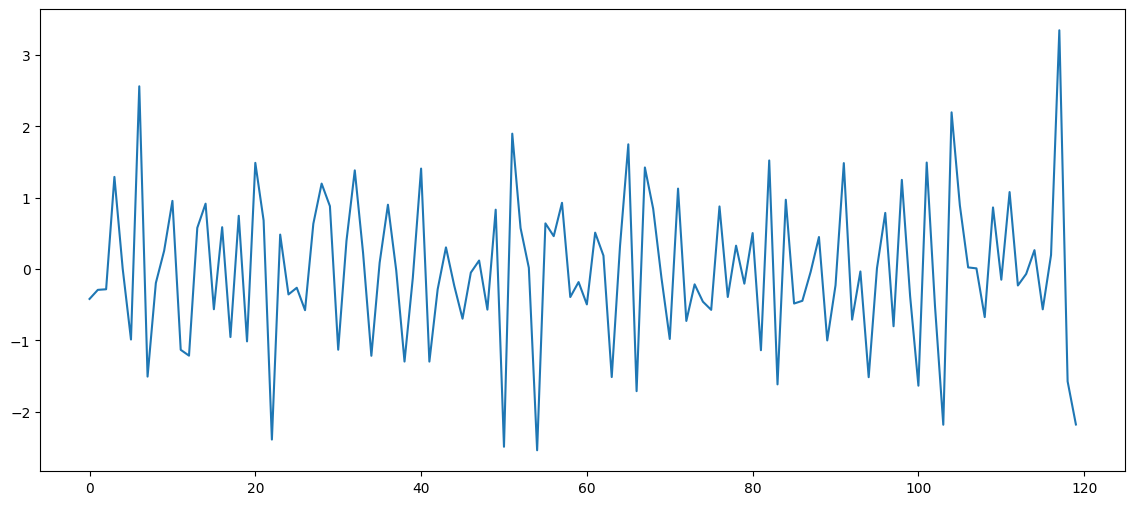

In [178]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(data_ma1); plt.show()

Berdasarkan plot deret waktu hasil simulasi, data berfluktuasi di sekitar rata-rata yang relatif konstan dan tidak menunjukkan adanya tren, pola musiman, maupun perubahan level yang jelas. Oleh karena itu, pembagian data dilakukan secara kronologis dengan proporsi 80% sebagai data training dan 20% sebagai data testing. Dari 120 observasi, sebanyak 96 observasi pertama digunakan sebagai data training dan 24 observasi terakhir digunakan sebagai data testing. Proporsi tersebut dipilih agar data training tetap cukup untuk proses estimasi model, sedangkan data testing memiliki jumlah observasi yang memadai untuk mengevaluasi kemampuan peramalan model.

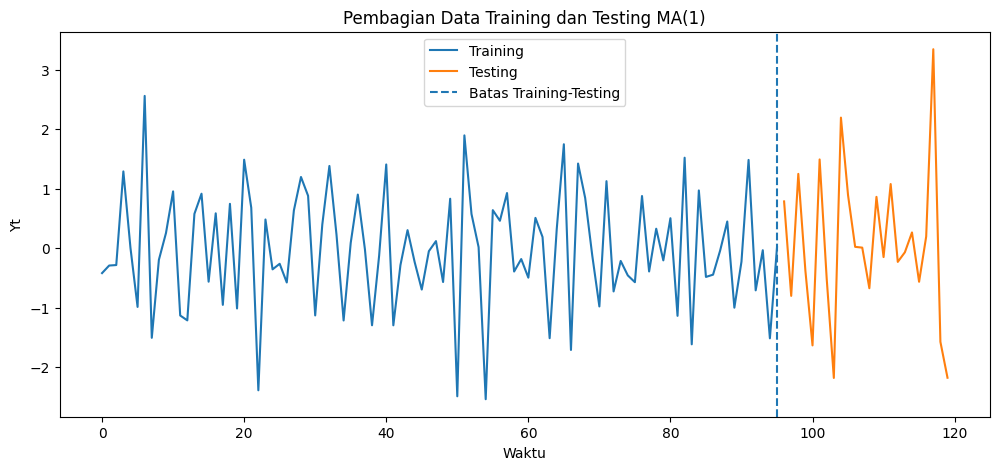

In [179]:
import matplotlib.pyplot as plt

# Membagi data 80:20
train_size = int(0.8 * len(data_ma1))

train_ma1 = data_ma1[:train_size]
test_ma1 = data_ma1[train_size:]

# Plot
plt.figure(figsize=(12, 5))

plt.plot(range(len(train_ma1)), train_ma1, label='Training')
plt.plot(range(len(train_ma1), len(data_ma1)), test_ma1, label='Testing')

# Garis pemisah
plt.axvline(x=train_size - 1, linestyle='--', label='Batas Training-Testing')

plt.title('Pembagian Data Training dan Testing MA(1)')
plt.xlabel('Waktu')
plt.ylabel('Yt')
plt.legend()
plt.show()

# 3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.

## Uji Stasioner dengan ADF

In [180]:
# Uji ADF pada data train
result = adfuller(train_ma1)

print("=== Uji ADF Data Train ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

=== Uji ADF Data Train ===
ADF Statistic : -9.7466
p-value       : 0.0000
Lags Used     : 2
Observations  : 93

Critical Values:
1%: -3.5027
5%: -2.8932
10%: -2.5836


Hipotesis ADF:

- H0: data tidak stasioner

- H1: data stasioner

dengan taraf signifikansi 5%:

- p-value $< 0.05$, tolak H0: stasioner

- p-value $\geq 0.05$, gagal menolak H0: belum stasioner

p-value: $0.000.. < 0.05$

**Data Train stasioner.**

## ACF dan PACF

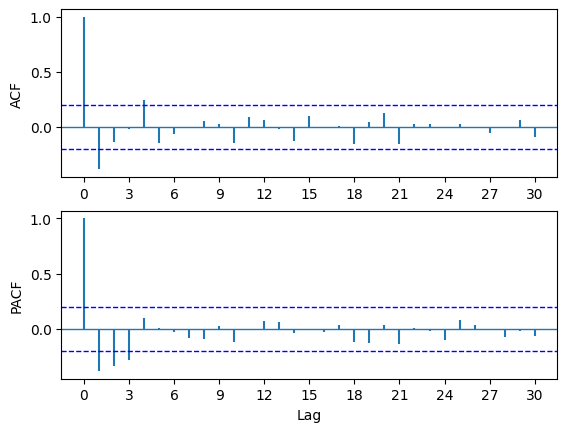

In [181]:
acf_pacf_fig(train_ma1, both=True, lag=30); plt.show()

Berdasarkan plot ACF, terlihat bahwa spike yang signifikan muncul pada lag ke-1, sedangkan lag-lag berikutnya sebagian besar berada di dalam batas signifikansi. Hal ini menunjukkan bahwa fungsi autokorelasi terputus pada lag ke-1. Sementara itu, plot PACF menunjukkan pola yang menurun secara bertahap (tailing off) tanpa adanya cut-off yang tegas. Pola ACF dan PACF tersebut mengindikasikan bahwa model tentatif yang sesuai adalah MA(1). Hasil ini juga didukung oleh plot EACF yang mengarah pada kombinasi ordo \((p,q)=(0,1)\).

## EACF

In [182]:
!pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [183]:
import warnings
warnings.filterwarnings("ignore")

#Jalankan syntax ini cukup satu kali, jangan berulang
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [184]:
%%R
install.packages('TSA')
library(TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'
Content type 'application/x-gzip' length 207505 bytes (202 KB)
downloaded 202 KB


The downloaded source packages are in
	‘/tmp/RtmplkTXo0/downloaded_packages’


In [185]:
%%R -i train_ma1

eacf(as.numeric(train_ma1))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o x o o o o o o o  o  o  o 
1 x o o x o o o o o o o  o  o  o 
2 x o x o o o o o o o o  o  o  o 
3 x o o o o o o o o o o  o  o  o 
4 o o o o x o o o o o o  o  o  o 
5 x o o o o o o o o o o  o  o  o 
6 x o o o o o x o o o o  o  o  o 
7 x x o x o o x o o o o  o  o  o 


Berdasarkan hasil EACF, terlihat pola segitiga yang didominasi oleh tanda o dengan titik awal yang mengarah pada kombinasi \(p=0\) dan \(q=1\). Oleh karena itu, model tentatif yang diperoleh dari EACF adalah ARMA(0,1) atau MA(1).

In [186]:
model_ma1 = ARIMA(
    train_ma1,
    order=(0,0,1)
).fit()

print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -119.756
Date:                Wed, 23 Sep 2026   AIC                            245.513
Time:                        04:54:41   BIC                            253.206
Sample:                             0   HQIC                           248.622
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0277      0.032     -0.872      0.383      -0.090       0.035
ma.L1         -0.6415      0.090     -7.136      0.000      -0.818      -0.465
sigma2         0.7058      0.104      6.817      0.0

## 4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

In [187]:
residual_ma1 = model_ma1.resid
residual_ma1

array([-3.90505805e-01, -4.40775610e-01, -5.07515311e-01,  1.00818660e+00,
        6.69305684e-01, -5.32895947e-01,  2.24895862e+00, -3.80437371e-02,
       -1.91454684e-01,  1.61813671e-01,  1.08768989e+00, -4.05935789e-01,
       -1.44588958e+00, -3.21643548e-01,  7.38523869e-01, -6.12313246e-02,
        5.75677023e-01, -5.55401490e-01,  4.18525190e-01, -7.16960454e-01,
        1.05676827e+00,  1.38774519e+00, -1.47126134e+00, -4.32465624e-01,
       -6.04828901e-01, -6.22011850e-01, -9.47229388e-01,  5.57901242e-02,
        1.26181117e+00,  1.71939018e+00,  6.56742377e-04,  4.26462713e-01,
        1.68509599e+00,  1.33595270e+00, -3.30287105e-01, -9.42788990e-02,
        8.69544923e-01,  5.67503415e-01, -9.04085755e-01, -6.76731876e-01,
        1.00254950e+00, -6.25639637e-01, -6.56695547e-01, -8.90980611e-02,
       -2.62214995e-01, -8.35613648e-01, -5.57859191e-01, -2.10208840e-01,
       -6.74999639e-01,  4.27447955e-01, -2.18825365e+00,  5.22094050e-01,
        9.38750774e-01,  

### LJung Box

In [188]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residual_ma1,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10  10.118956   0.430120
20  19.548020   0.486503


**Ljung Box**

Hipotesis:

- H0: residual tidak memiliki autokorelasi

- H1: residual memiliki autokorelasi

Interpretasi:

- Jika p-value $> 0.05$, H0 tidak ditolak.

- Jika p-value $< 0.05$, H0 ditolak.

Karena p-value > 0.05, maka tidak bukti bahwa residual memiliki autokorelasi.

### Jarque Bera

In [189]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(
    residual_ma1[1:]
)

print("=== Uji Jarque-Bera ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skew:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

=== Uji Jarque-Bera ===
JB Statistic : 0.2685
p-value      : 0.8744
Skewness     : 0.1247
Kurtosis     : 2.9250


**Uji Jarque-Bera**

Hipotesis:

- H0: residual berdistribusi normal.

- H1: residual tidak berdistribusi normal.

Interpretasi:

- p-value $> 0.05$, **tidak** ada bukti residual **tidak normal.**

- p-value $< 0.05$, residual berbeda secara signifikan dari normal

Karena p-value > 0.05, residual berdistribusi normal.

### ARCH (Uji Heteroskedastisitas)

In [190]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residual_ma1)

print("=== Uji ARCH ===")
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"LM p-value   : {arch_test[1]:.4f}")
print(f"F Statistic  : {arch_test[2]:.4f}")
print(f"F p-value    : {arch_test[3]:.4f}")

=== Uji ARCH ===
LM Statistic : 7.8259
LM p-value   : 0.6458
F Statistic  : 0.7508
F p-value    : 0.6747


**Uji Heteroskedastisitas**

Hipotesis:

- H0: tidak terdapat efek heteroskedastisitas

- H1: terdapat heteroskedastisitas

Interpretasi:

- p-value $> 0,05$, tidak ada bukti heteroskedastisitas.

- p-value $< 0.05$, terdapat indikasi heteroskedastisitas.

Karena p-value > 0.05, maka tidak ada bukti residual heteroskedastisitas.

**Hasil**

Ljung-Box → p-value > 0,05 ✅

Jarque-Bera → p-value > 0,05 ✅

ARCH → p-value > 0,05 ✅

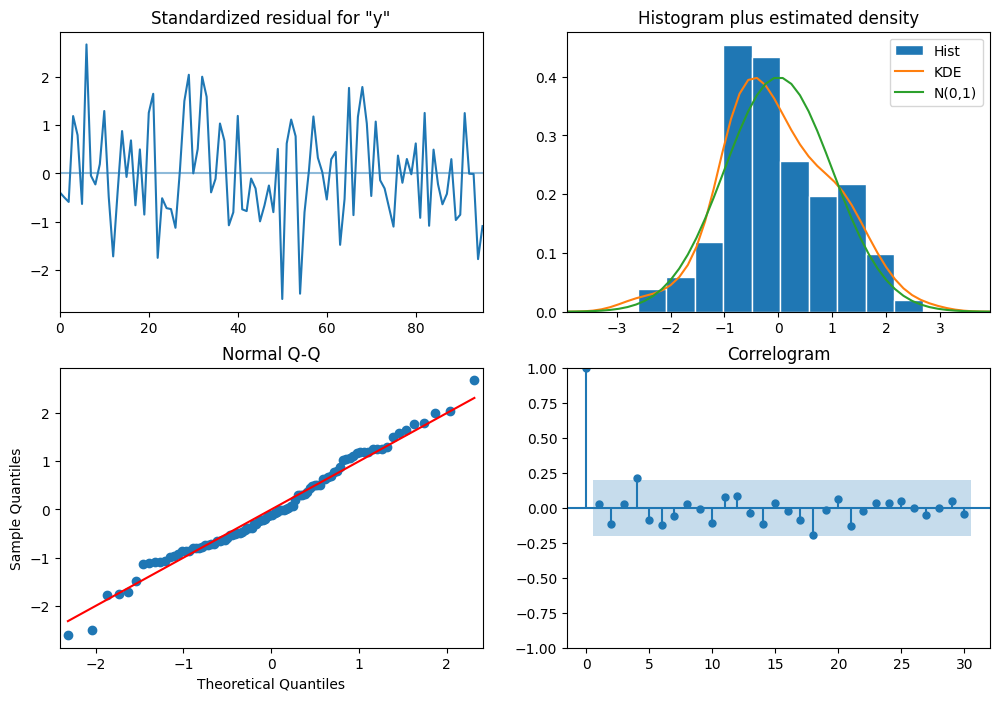

In [191]:
model_ma1.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

## Overfitting

In [192]:
#Model MA(2)
model_ma2 = ARIMA(
    train_ma1,
    order=(0,0,2)
).fit()

print(model_ma2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -119.555
Date:                Wed, 23 Sep 2026   AIC                            247.110
Time:                        04:54:42   BIC                            257.367
Sample:                             0   HQIC                           251.256
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0273      0.030     -0.918      0.359      -0.086       0.031
ma.L1         -0.5921      0.114     -5.206      0.000      -0.815      -0.369
ma.L2         -0.0765      0.111     -0.689      0.4

In [193]:
#Model ARMA(1,1)
model_arma11=ARIMA(train_ma1,order=(1,0,1)).fit()
print(model_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -119.621
Date:                Wed, 23 Sep 2026   AIC                            247.243
Time:                        04:54:43   BIC                            257.500
Sample:                             0   HQIC                           251.389
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0274      0.030     -0.906      0.365      -0.087       0.032
ar.L1          0.0829      0.170      0.487      0.626      -0.251       0.417
ma.L1         -0.6908      0.129     -5.350      0.0

In [194]:
pd.DataFrame({
    'Model': ['MA(1)', 'MA(2)', 'ARMA(1,1)'],
    'AIC': [
        model_ma1.aic,
        model_ma2.aic,
        model_arma11.aic
    ],
    'BIC': [
        model_ma1.bic,
        model_ma2.bic,
        model_arma11.bic
    ]
})

,Model,AIC,BIC
0,MA(1),245.512783,253.205828
1,MA(2),247.109530,257.366923
2,"ARMA(1,1)",247.242668,257.500061


# 5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

## Peramalan

In [195]:
prediksi_test_ma1 = model_ma1.get_forecast(
    test_ma1.shape[0]
).summary_frame(alpha=0.05)

prediksi_test_ma1

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.561161,0.840095,-1.085395,2.207716
1,-0.027707,0.998106,-1.983959,1.928544
2,-0.027707,0.998106,-1.983959,1.928544
3,-0.027707,0.998106,-1.983959,1.928544
4,-0.027707,0.998106,-1.983959,1.928544
5,-0.027707,0.998106,-1.983959,1.928544
6,-0.027707,0.998106,-1.983959,1.928544
7,-0.027707,0.998106,-1.983959,1.928544
8,-0.027707,0.998106,-1.983959,1.928544
9,-0.027707,0.998106,-1.983959,1.928544


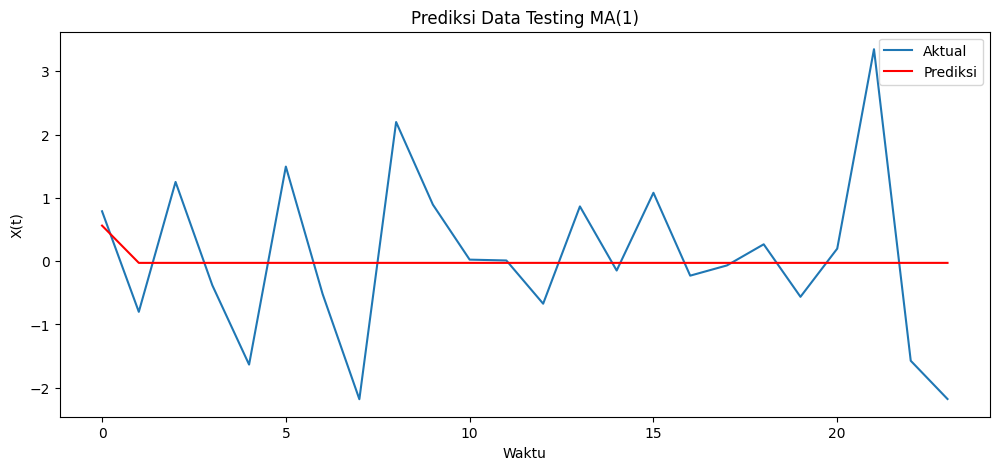

In [196]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ma1,
    label='Aktual'
)

plt.plot(
    prediksi_test_ma1['mean'].values,
    color='red',
    label='Prediksi'
)

plt.title('Prediksi Data Testing MA(1)')
plt.xlabel('Waktu')
plt.ylabel('X(t)')
plt.legend()
plt.show()

Hasil peramalan model MA(1) menunjukkan bahwa prediksi pada periode pertama masih dipengaruhi oleh galat pada periode terakhir data training. Setelah horizon pertama, nilai ramalan dengan cepat kembali mendekati rata-rata jangka panjang deret, yaitu sekitar nol. Hal tersebut sesuai dengan karakteristik model MA(1), karena pengaruh suatu shock hanya berlangsung selama satu periode. Oleh karena itu, ramalan beberapa langkah ke depan pada model MA(1) cenderung konstan pada nilai rata-rata proses.

## RMSE dan MAPE

In [197]:
def RMSE(actual, predicted):
    return np.sqrt(
        np.mean(
            (np.array(actual) - np.array(predicted))**2
        )
    )

def MAPE(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    return np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

In [198]:
prediksi_train_ma1 = model_ma1.fittedvalues

In [199]:
rmse_train_ma1 = RMSE(
    train_ma1,
    prediksi_train_ma1
)

mape_train_ma1 = MAPE(
    train_ma1,
    prediksi_train_ma1
)

rmse_test_ma1 = RMSE(
    test_ma1,
    prediksi_test_ma1['mean'].values
)

mape_test_ma1 = MAPE(
    test_ma1,
    prediksi_test_ma1['mean'].values
)

pd.DataFrame({
    'Data': ['Training', 'Testing'],
    'RMSE': [
        rmse_train_ma1,
        rmse_test_ma1
    ],
    'MAPE (%)': [
        mape_train_ma1,
        mape_test_ma1
    ]
})

,Data,RMSE,MAPE (%)
0,Training,0.840738,387.790828
1,Testing,1.279803,110.667024


Nilai RMSE data training sebesar sekitar 0,8407 dan RMSE testing sekitar 1,2798. Nilai RMSE testing lebih besar daripada training, yang menunjukkan bahwa galat peramalan pada data baru lebih besar dibandingkan galat pengepasan pada data training. Nilai MAPE relatif sangat besar karena data simulasi dapat memiliki nilai aktual yang mendekati nol. Oleh karena itu, MAPE kurang stabil untuk deret simulasi ini dan interpretasi performa model sebaiknya lebih menekankan RMSE dan hasil diagnostik sisaan.

# 6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

## AR(2)

### 1. Deret simulasi AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$

In [200]:
from statsmodels.tsa.arima_process import ArmaProcess
# Seed
np.random.seed(104)

# Parameter AR(2)
phi1 = 0.9
phi2 = -0.5

# AR(2): [1, -phi1, -phi2]
ar_ar2 = np.array([1, -phi1, -phi2])
ma_ar2 = np.array([1])

# Simulasi data
data_ar2 = ArmaProcess(ar_ar2, ma_ar2).generate_sample(nsample=100)

# Tampilkan data
print(data_ar2)

[-0.41821323 -0.91832552 -1.22529625  0.28396276  1.43062667  0.49604905
  1.90354751  1.2618072  -0.1329319  -0.6837087   0.44741204  0.21089762
 -1.56725811 -1.85778171 -0.17629709  0.63475144  1.16539252  0.08263915
 -0.1505034  -0.97524354  0.20745755  1.96238503  0.04600918 -1.42595422
 -1.95316498 -1.69465986 -1.51438628 -0.45933037  1.5758813   3.26941131
  1.997322    0.46689359  0.98775175  1.82247206  0.63147522 -0.56193209
 -0.05057115  0.67995799 -0.39190841 -1.43463762 -0.13140304 -0.11915975
 -0.7555124  -0.74428346 -0.59920417 -1.04650926 -1.2193777  -0.80049484
 -0.81439546  0.07787656 -1.76654117 -1.07691999  0.82129372  1.84016346
 -0.95637407 -2.46121075 -1.683388    0.67656547  1.63560255  1.06289389
 -0.39864673 -0.70189159 -0.13035583 -1.09822871 -1.39733907  0.75599316
  0.54695514  1.03932101  2.06294035  2.05384704  0.26795569  0.01298731
 -0.36945334 -0.7010592  -1.12024646 -1.63338683 -0.61702624  0.04646775
  0.54992006  0.38711246  0.52754649 -0.58330438  0

### 2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

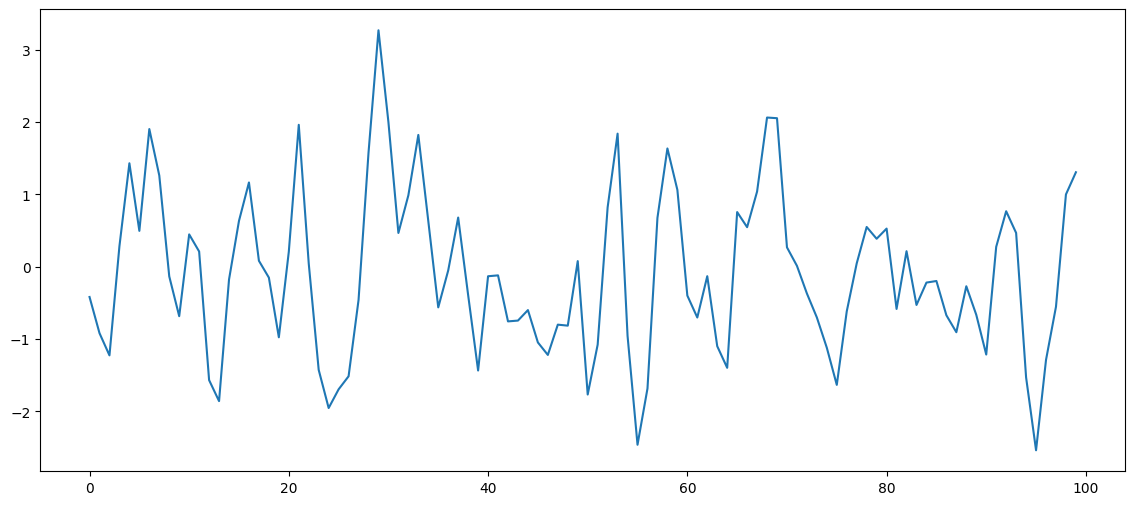

In [201]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(data_ar2); plt.show()

Berdasarkan plot deret waktu, data AR(2) dengan parameter ($\phi_1=0.9$) dan ($\phi_2=-0.5$) menunjukkan pola yang berfluktuasi di sekitar nilai rata-rata yang relatif konstan, yaitu sekitar nol. Nilai deret waktu bergerak naik dan turun secara bergantian tanpa menunjukkan adanya tren naik atau turun yang konsisten. Terlihat beberapa fluktuasi yang cukup besar, tetapi secara umum deret tetap berada dalam kisaran yang relatif stabil. Pola ini menunjukkan adanya ketergantungan nilai saat ini terhadap nilai pada beberapa periode sebelumnya, yang sesuai dengan karakteristik proses AR(2).

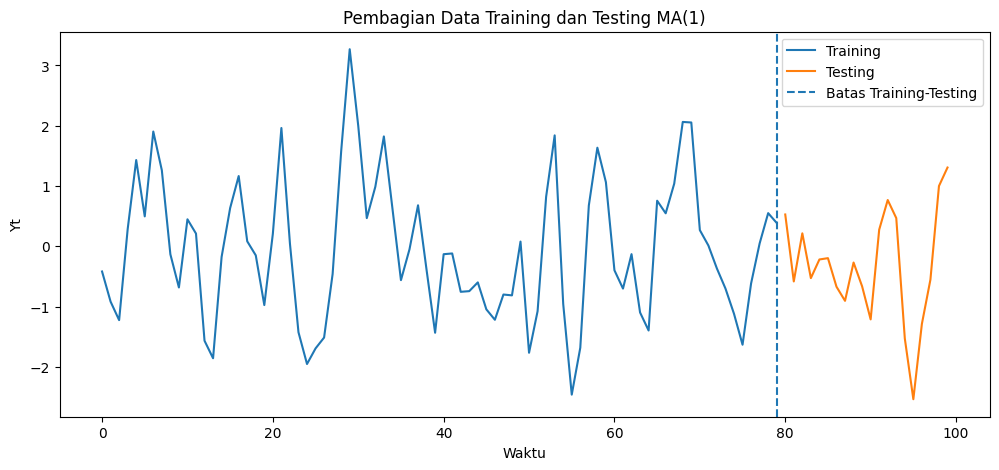

In [202]:
import matplotlib.pyplot as plt

# Membagi data 80:20
train_size = int(0.8 * len(data_ar2))

train_ar2 = data_ar2[:train_size]
test_ar2 = data_ar2[train_size:]

# Plot
plt.figure(figsize=(12, 5))

plt.plot(range(len(train_ar2)), train_ar2, label='Training')
plt.plot(range(len(train_ar2), len(data_ar2)), test_ar2, label='Testing')

# Garis pemisah
plt.axvline(x=train_size - 1, linestyle='--', label='Batas Training-Testing')

plt.title('Pembagian Data Training dan Testing MA(1)')
plt.xlabel('Waktu')
plt.ylabel('Yt')
plt.legend()
plt.show()

### 3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.

**a. Uji Stasioner dengan ADF**

In [203]:
# Uji ADF pada data train
result = adfuller(train_ar2)

print("=== Uji ADF Data Train ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

=== Uji ADF Data Train ===
ADF Statistic : -4.2737
p-value       : 0.0005
Lags Used     : 2
Observations  : 77

Critical Values:
1%: -3.5183
5%: -2.8999
10%: -2.5872


Hipotesis ADF:

- H0: data tidak stasioner

- H1: data stasioner

dengan taraf signifikansi 5%:

- p-value $< 0.05$, tolak H0: stasioner

- p-value $\geq 0.05$, gagal menolak H0: belum stasioner

p-value: $0.0005 < 0.05$

**Data Train stasioner.**

**b. ACF dan PACF**

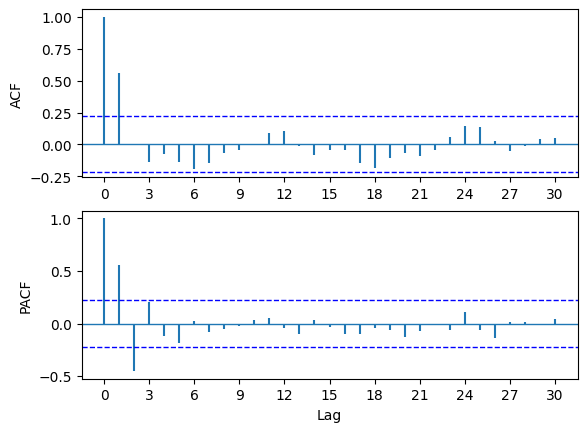

In [204]:
acf_pacf_fig(train_ar2, both=True, lag=30); plt.show()

ACF: Pada lag 1 terlihat nilai autokorelasi positif yang signifikan karena melewati batas signifikansi. Setelah lag 1, sebagian besar nilai ACF berada di dalam batas signifikansi, meskipun terdapat beberapa spike negatif pada lag sekitar 3–8 dan 16–19 yang masih menunjukkan fluktuasi kecil. Pola ACF yang menunjukkan penurunan setelah lag 1 mengindikasikan adanya ketergantungan deret waktu terutama pada lag awal.

PACF: Pada lag 1 terdapat nilai positif yang signifikan, sedangkan pada lag 2 terdapat nilai negatif yang juga signifikan. Setelah lag 2, sebagian besar nilai PACF berada di dalam batas signifikansi. Pola PACF yang terputus setelah lag 2 mengindikasikan bahwa model AR(2) sesuai untuk menggambarkan struktur ketergantungan data, atau dapat dinyatakan sebagai ARIMA(2,0,0).

**c. EACF**

In [205]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [206]:
%%R
library(TSA)

In [207]:
%%R -i train_ar2

eacf(as.numeric(train_ar2))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x o o o o o o o o o o  o  o  o 
2 x o x o o o o o o o o  o  o  o 
3 x o x o x o o o o o o  o  o  o 
4 x x x o o o o o o o o  o  o  o 
5 o x x o o o o o o o o  o  o  o 
6 x x x o o o o o o o o  o  o  o 
7 x o o o o o o o o o o  o  o  o 


Berdasarkan hasil EACF, terlihat pola segitiga nilai o yang mulai terbentuk pada AR = 1 dan MA = 1, sehingga kandidat model yang diperoleh adalah ARMA(1,1) atau ARIMA(1,0,1). Selain itu, AR = 2 dan MA = 1 juga bisa menjadi kandidat model terbaik. Hasil ini selanjutnya perlu dibandingkan dengan kandidat AR(2) berdasarkan kriteria AIC, BIC, serta diagnostik residual untuk menentukan model yang sesuai.

In [208]:
# ARIMA(1,0,1)
model_101 = ARIMA(
    train_ar2,
    order=(1,0,1)
).fit()

# ARIMA(2,0,1)
model_201 = ARIMA(
    train_ar2,
    order=(2,0,1)
).fit()

# Perbandingan AIC dan BIC
perbandingan_model = pd.DataFrame({
    'Model': ['ARIMA(1,0,1)', 'ARIMA(2,0,1)'],
    'AIC': [model_101.aic, model_201.aic],
    'BIC': [model_101.bic, model_201.bic]
})

print(perbandingan_model)

          Model         AIC         BIC
0  ARIMA(1,0,1)  211.137477  220.665584
1  ARIMA(2,0,1)  209.291379  221.201513


Berdasarkan nilai AIC dan BIC, ARIMA(1,0,1) memiliki nilai AIC sebesar 211,1375 dan BIC sebesar 220,6656, sedangkan ARIMA(2,0,1) memiliki nilai AIC sebesar 209,2914 dan BIC sebesar 221,2015. Model ARIMA(2,0,1) memiliki AIC yang lebih kecil, tetapi memiliki BIC yang sedikit lebih besar dibandingkan ARIMA(1,0,1). Karena AIC dan BIC memberikan hasil yang berbeda, pemilihan model berdasarkan kedua kriteria tersebut tidak menunjukkan satu model yang unggul secara bersamaan. Namun, jika mempertimbangkan BIC yang memberikan penalti lebih besar terhadap kompleksitas model, ARIMA(1,0,1) dapat dipilih sebagai model yang lebih parsimonious.

### 4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

In [209]:
residual_ar2 = model_101.resid
residual_ar2

array([-0.36120886, -0.64403509, -0.60267967,  1.00245599,  0.82086751,
       -0.33627037,  1.99930471, -0.38535496, -0.22341523, -0.47637697,
        0.95537   , -0.42538326, -1.33974021, -0.6032977 ,  0.73436977,
        0.30109427,  0.85442058, -0.69678129,  0.26974386, -1.04779568,
        1.12723388,  1.2941642 , -1.21098918, -0.69845236, -1.10869692,
       -0.46534169, -0.72916094,  0.42768402,  1.49875726,  2.0026902 ,
       -0.03558455, -0.03191865,  0.91620409,  1.05720839, -0.44941636,
       -0.43853208,  0.4013688 ,  0.50334937, -0.83237482, -0.80293861,
        0.77584665, -0.48936728, -0.39843849, -0.26118781, -0.19852723,
       -0.72272545, -0.46734913, -0.14745677, -0.46363233,  0.61514493,
       -2.10265255,  0.67409133,  0.77513154,  1.20307735, -2.12647492,
       -0.92374399, -0.41834934,  1.43148819,  0.66004714,  0.26380903,
       -0.8082058 , -0.08226072,  0.15508929, -1.11021548, -0.40700747,
        1.42411068, -0.44662392,  1.18482148,  1.12806993,  0.86

**a. LJung Box**

In [210]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residual_ar2,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10   8.010112   0.627849
20  13.492060   0.855289


**Ljung Box**

Hipotesis:

- H0: residual tidak memiliki autokorelasi

- H1: residual memiliki autokorelasi

Interpretasi:

- Jika p-value $> 0.05$, H0 tidak ditolak.

- Jika p-value $< 0.05$, H0 ditolak.

Karena p-value > 0.05, maka tidak bukti bahwa residual memiliki autokorelasi.

**b. Jarque Bera**

In [211]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(
    residual_ar2[1:]
)

print("=== Uji Jarque-Bera ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skew:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

=== Uji Jarque-Bera ===
JB Statistic : 0.5661
p-value      : 0.7535
Skewness     : 0.1361
Kurtosis     : 2.6872


**Uji Jarque-Bera**

Hipotesis:

- H0: residual berdistribusi normal.

- H1: residual tidak berdistribusi normal.

Interpretasi:

- p-value $> 0.05$, **tidak** ada bukti residual **tidak normal.**

- p-value $< 0.05$, residual berbeda secara signifikan dari normal

Karena p-value > 0.05, residual berdistribusi normal.

**c. ARCH (Uji Heteroskedastisitas)**

In [212]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residual_ar2)

print("=== Uji ARCH ===")
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"LM p-value   : {arch_test[1]:.4f}")
print(f"F Statistic  : {arch_test[2]:.4f}")
print(f"F p-value    : {arch_test[3]:.4f}")

=== Uji ARCH ===
LM Statistic : 5.7242
LM p-value   : 0.8379
F Statistic  : 0.5254
F p-value    : 0.8654


**Uji Heteroskedastisitas**

Hipotesis:

- H0: tidak terdapat efek heteroskedastisitas

- H1: terdapat heteroskedastisitas

Interpretasi:

- p-value $> 0,05$, tidak ada bukti heteroskedastisitas.

- p-value $< 0.05$, terdapat indikasi heteroskedastisitas.

Karena p-value > 0.05, maka tidak ada bukti residual heteroskedastisitas.

**Hasil**

Ljung-Box → p-value > 0,05 ✅

Jarque-Bera → p-value > 0,05 ✅

ARCH → p-value > 0,05 ✅

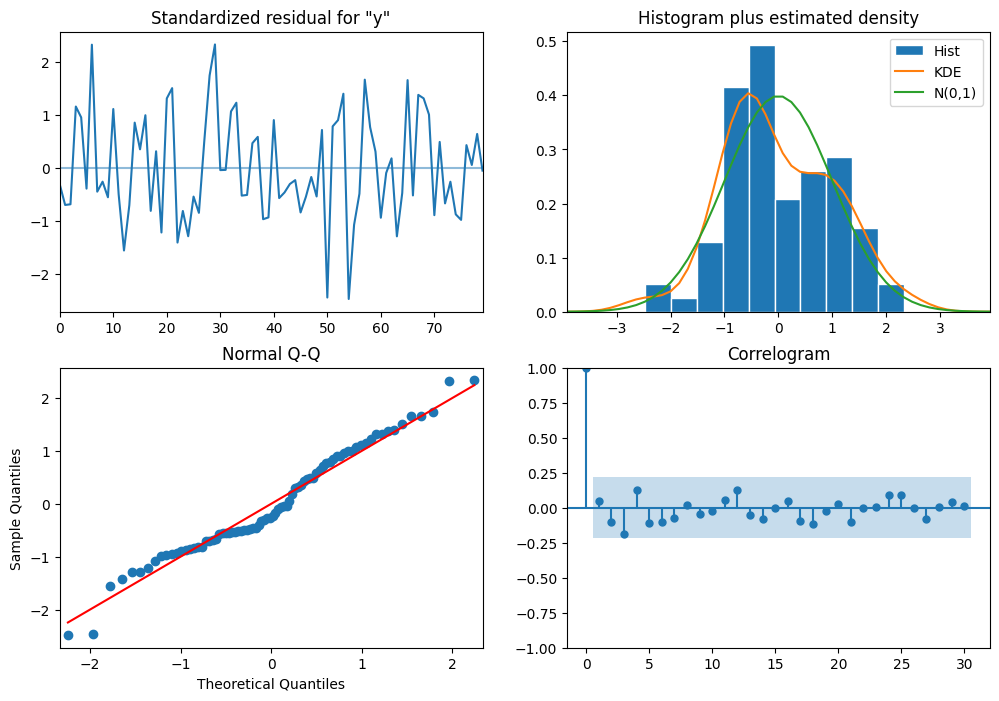

In [214]:
model_101.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

**d. Overfitting**

In [215]:
# Model AR(2)
model_ar2 = ARIMA(
    train_ar2,
    order=(2,0,0)
).fit()

# Model AR(3) sebagai overfit
model_ar3 = ARIMA(
    train_ar2,
    order=(3,0,0)
).fit()

print("=== AR(2) ===")
print(model_ar2.summary())

print("\n=== AR(3) ===")
print(model_ar3.summary())

=== AR(2) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -101.324
Date:                Wed, 23 Sep 2026   AIC                            210.648
Time:                        04:56:31   BIC                            220.176
Sample:                             0   HQIC                           214.468
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0539      0.156     -0.345      0.730      -0.360       0.252
ar.L1          0.8039      0.105      7.662      0.000       0.598       1.010
ar.L2         -0.4437      0.105     -

In [216]:
pd.DataFrame({
    'Model': ['AR(2)', 'AR(3)'],
    'AIC': [
        model_ar2.aic,
        model_ar3.aic
    ],
    'BIC': [
        model_ar2.bic,
        model_ar3.bic
    ]
})

,Model,AIC,BIC
0,AR(2),210.647701,220.175808
1,AR(3),209.261530,221.171663


Berdasarkan perbandingan nilai AIC dan BIC, model AR(3) memiliki nilai AIC sebesar 209,2615, lebih kecil dibandingkan AR(2) sebesar 210,6477. Namun, nilai BIC AR(3) sebesar 221,1717 justru sedikit lebih besar dibandingkan AR(2) sebesar 220,1758. Dengan demikian, AIC cenderung mendukung AR(3), sedangkan BIC mendukung AR(2). Karena BIC memberikan penalti yang lebih besar terhadap kompleksitas model, AR(2) dapat dipertahankan sebagai model yang lebih parsimonious, sehingga penambahan lag ke-3 tidak memberikan perbaikan yang cukup berdasarkan BIC.

### 5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

**a. Peramalan**

In [217]:
prediksi_test_ar2 = model_101.get_forecast(
    test_ar2.shape[0]
).summary_frame(alpha=0.05)

prediksi_test_ar2

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.042118,0.857049,-1.637666,1.721903
1,-0.029194,1.129338,-2.242655,2.184267
2,-0.049202,1.148032,-2.299304,2.200900
3,-0.054815,1.149491,-2.307776,2.198146
4,-0.056390,1.149606,-2.309576,2.196796
5,-0.056832,1.149615,-2.310036,2.196372
6,-0.056956,1.149616,-2.310161,2.196249
7,-0.056991,1.149616,-2.310196,2.196214
8,-0.057001,1.149616,-2.310206,2.196205
9,-0.057003,1.149616,-2.310208,2.196202


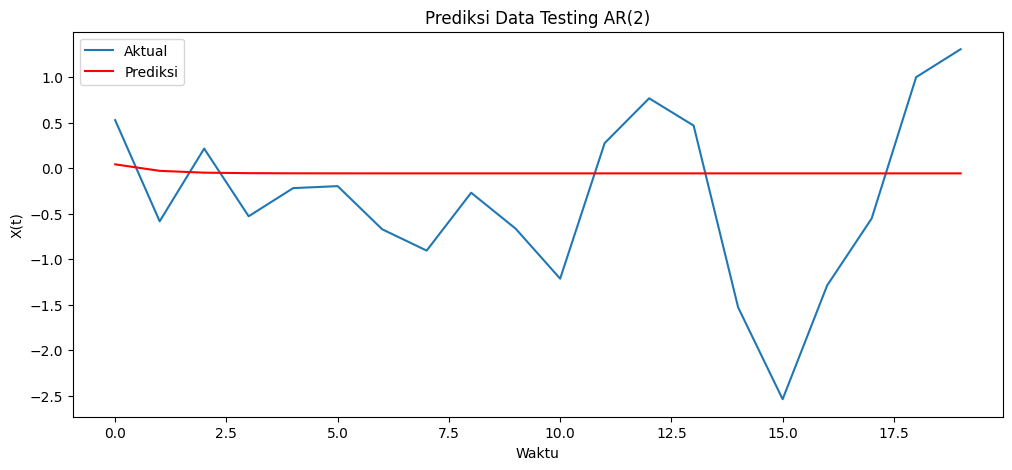

In [218]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ar2,
    label='Aktual'
)

plt.plot(
    prediksi_test_ar2['mean'].values,
    color='red',
    label='Prediksi'
)

plt.title('Prediksi Data Testing AR(2)')
plt.xlabel('Waktu')
plt.ylabel('X(t)')
plt.legend()
plt.show()

Berdasarkan grafik peramalan data testing AR(2), terlihat bahwa nilai aktual (garis biru) berfluktuasi cukup besar, sedangkan hasil prediksi (garis merah) cenderung mendatar di sekitar nilai nol. Prediksi belum mampu mengikuti perubahan naik-turun data aktual, terutama pada saat terjadi nilai ekstrem seperti sekitar waktu ke-10 hingga ke-19.

Hal tersebut menunjukkan bahwa kemampuan AR(2) dalam memprediksi data testing masih terbatas, khususnya dalam menangkap fluktuasi jangka pendek dan nilai ekstrem. Meskipun model dapat memberikan prediksi yang stabil di sekitar rata-rata, hasil peramalan belum mengikuti pola aktual dengan baik.

**b. RMSE dan MAPE**

In [219]:
def RMSE(actual, predicted):
    return np.sqrt(
        np.mean(
            (np.array(actual) - np.array(predicted))**2
        )
    )

def MAPE(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    return np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

In [221]:
prediksi_train_ar2 = model_101.fittedvalues

In [220]:
# Prediksi data training
prediksi_train_ar2 = model_101.predict(
    start=0,
    end=len(train_ar2)-1
)

# Prediksi data testing
prediksi_test_ar2 = model_101.get_forecast(
    steps=len(test_ar2)
).summary_frame(alpha=0.05)

# RMSE
rmse_train_ar2 = RMSE(
    train_ar2,
    prediksi_train_ar2
)

rmse_test_ar2 = RMSE(
    test_ar2,
    prediksi_test_ar2['mean'].values
)

# MAPE
mape_train_ar2 = MAPE(
    train_ar2,
    prediksi_train_ar2
)

mape_test_ar2 = MAPE(
    test_ar2,
    prediksi_test_ar2['mean'].values
)

# Tabel evaluasi
pd.DataFrame({
    'Data': ['Training', 'Testing'],
    'RMSE': [
        rmse_train_ar2,
        rmse_test_ar2
    ],
    'MAPE (%)': [
        mape_train_ar2,
        mape_test_ar2
    ]
})

,Data,RMSE,MAPE (%)
0,Training,0.858113,205.353800
1,Testing,0.944811,96.269302


Berdasarkan hasil evaluasi model ARIMA(1,0,1), nilai RMSE pada data training sebesar 0,8581, sedangkan pada data testing sebesar 0,9448. Nilai RMSE testing yang sedikit lebih besar dibandingkan training menunjukkan bahwa kesalahan prediksi meningkat pada data yang belum digunakan dalam pembentukan model, tetapi perbedaannya relatif kecil sehingga tidak menunjukkan indikasi overfitting yang kuat.

Sementara itu, nilai MAPE pada training sebesar 205,35% dan pada testing sebesar 96,27%. Nilai MAPE yang cukup besar menunjukkan persentase kesalahan prediksi yang tinggi. Namun, karena data simulasi AR(2) dapat memiliki nilai aktual yang mendekati nol, MAPE menjadi kurang stabil dan dapat menghasilkan nilai yang sangat besar. Oleh karena itu, RMSE lebih dapat diandalkan untuk mengevaluasi performa model pada data ini. Secara keseluruhan, ARIMA(1,0,1) memiliki performa prediksi yang relatif konsisten antara training dan testing, meskipun tingkat kesalahan prediksinya masih cukup besar.

## ARMA(1,1)

### 1. Deret simulasi ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$

In [222]:
from statsmodels.tsa.arima_process import ArmaProcess
np.random.seed(104)

ar_arma11 = np.array([
    1,
    -0.4
])

ma_arma11 = np.array([
    1,
    0.6
])

proses_arma11 = ArmaProcess(
    ar_arma11,
    ma_arma11
)

data_arma11 = proses_arma11.generate_sample(
    nsample=200
)

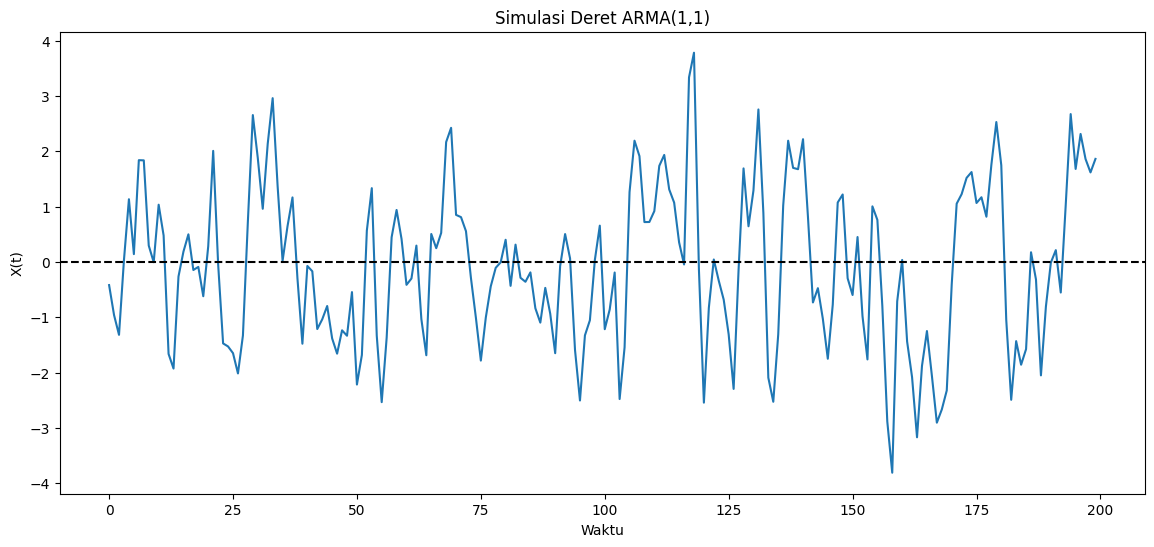

In [223]:
plt.figure(figsize=(14,6))
plt.plot(data_arma11)
plt.axhline(0, color='black', linestyle='--')
plt.title('Simulasi Deret ARMA(1,1)')
plt.xlabel('Waktu')
plt.ylabel('X(t)')
plt.show()

Berdasarkan plot deret ARMA(1,1), data menunjukkan fluktuasi di sekitar rata-rata yang relatif konstan tanpa adanya tren, pola musiman, maupun perubahan struktur yang jelas. Oleh karena itu, pembagian data dilakukan secara kronologis dengan proporsi 80% untuk data training dan 20% untuk data testing. Dari 200 observasi, sebanyak 160 observasi pertama digunakan sebagai data training dan 40 observasi terakhir sebagai data testing.

### 2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

In [224]:
size_train_arma11 = round(
    0.8 * len(data_arma11)
)

train_arma11 = data_arma11[
    :size_train_arma11
]

test_arma11 = data_arma11[
    size_train_arma11:
]

print(len(train_arma11))
print(len(test_arma11))

160
40


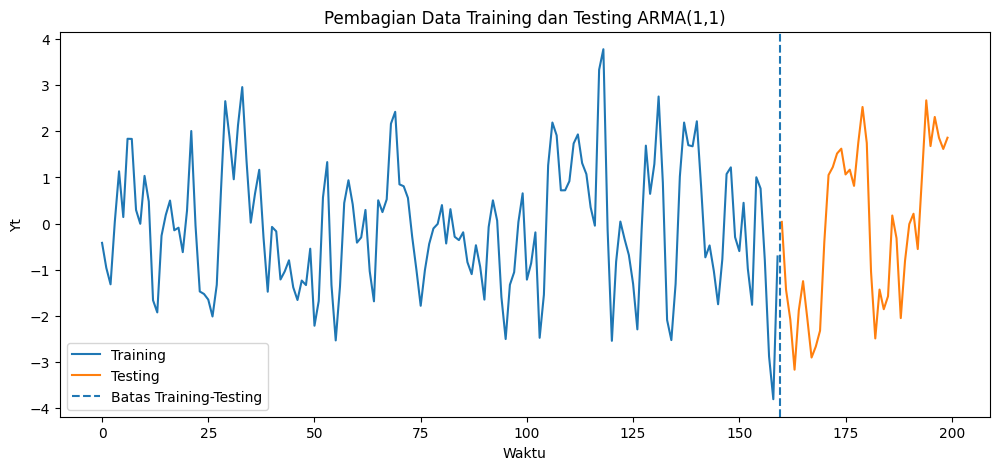

In [225]:
# Membagi data 80:20
train_size = int(0.8 * len(data_arma11))

train_ma11 = data_arma11[:train_size]
test_ma11 = data_arma11[train_size:]

# Plot
plt.figure(figsize=(12, 5))

plt.plot(range(len(train_arma11)), train_arma11, label='Training')
plt.plot(range(len(train_arma11), len(data_arma11)), test_arma11, label='Testing')

# Garis pemisah
plt.axvline(x=train_size - 0.5, linestyle='--', label='Batas Training-Testing')

plt.title('Pembagian Data Training dan Testing ARMA(1,1)')
plt.xlabel('Waktu')
plt.ylabel('Yt')
plt.legend()
plt.show()

### 3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.

**a. Uji Stasioner dengan ADF**

In [226]:
# Uji ADF pada data train
result = adfuller(train_arma11)

print("=== Uji ADF Data Train ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

=== Uji ADF Data Train ===
ADF Statistic : -5.8572
p-value       : 0.0000
Lags Used     : 3
Observations  : 156

Critical Values:
1%: -3.4730
5%: -2.8803
10%: -2.5767


Hipotesis ADF:

- H0: data tidak stasioner

- H1: data stasioner

dengan taraf signifikansi 5%:

- p-value $< 0.05$, tolak H0: stasioner

- p-value $\geq 0.05$, gagal menolak H0: belum stasioner

p-value: $0.0005 < 0.05$

**Data Train stasioner.**

**b. ACF dan PACF**

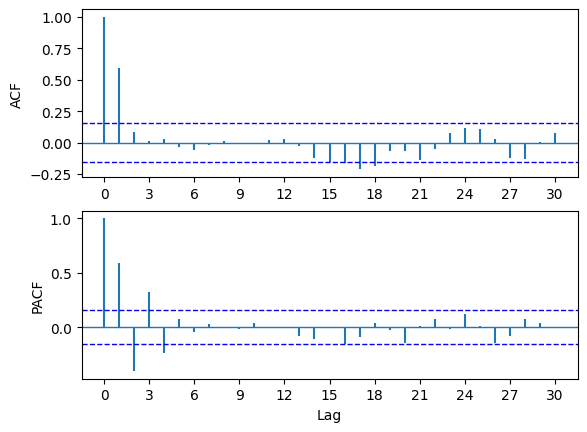

In [227]:
acf_pacf_fig(
    train_arma11,
    both=True,
    lag=30
)

plt.show()

Plot ACF dan PACF sama-sama tidak menunjukkan pola cut-off yang tegas dan cenderung menurun secara bertahap. Kondisi tersebut mengindikasikan adanya kombinasi komponen AR dan MA sehingga model ARMA layak dipertimbangkan.

**c. EACF**

In [228]:
%%R -i train_arma11

eacf(as.numeric(train_arma11))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x o o o o o o o o o o  o  o  o 
2 x o o o o o o o o o o  o  o  o 
3 x x o x o o o o o o o  o  o  o 
4 x o o x x o o o o o o  o  o  o 
5 x x o o o x o o o o o  o  o  o 
6 x x o o o x o o o o o  o  o  o 
7 x x o o o o o o o o o  o  o  o 


Berdasarkan plot ACF, terlihat spike yang signifikan pada lag pertama dan lag-lag berikutnya sebagian besar berada di dalam batas signifikansi, sehingga ACF cenderung menunjukkan pola cut-off setelah lag pertama. Sementara itu, PACF menunjukkan pola yang menurun secara bertahap dan berosilasi, sehingga mengarah pada model MA. Hasil EACF menunjukkan pola segitiga tanda o yang mulai terlihat pada kombinasi (p=0,q=1), serta mencakup kombinasi (p=1,q=1). Oleh karena itu, model tentatif yang dapat dipertimbangkan adalah MA(1) dan ARMA(1,1).

In [229]:
# Kandidat 1: MA(1)
model_ma1 = ARIMA(train_arma11, order=(0,0,1)).fit()
print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -220.413
Date:                Wed, 23 Sep 2026   AIC                            446.827
Time:                        04:57:19   BIC                            456.052
Sample:                             0   HQIC                           450.573
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0748      0.138     -0.541      0.588      -0.346       0.196
ma.L1          0.8242      0.050     16.391      0.000       0.726       0.923
sigma2         0.9141      0.098      9.361      0.0

In [230]:
# Kandidat 2: ARMA(1,1)
model_arma11 = ARIMA(train_arma11, order=(1,0,1)).fit()
print(model_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -215.734
Date:                Wed, 23 Sep 2026   AIC                            439.467
Time:                        04:57:22   BIC                            451.768
Sample:                             0   HQIC                           444.462
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0725      0.177     -0.409      0.683      -0.420       0.275
ar.L1          0.2742      0.095      2.889      0.004       0.088       0.460
ma.L1          0.7476      0.066     11.274      0.0

Berdasarkan hasil pengepasan, model MA(1) menghasilkan parameter MA(1) yang signifikan dengan nilai AIC sebesar 446,827 dan BIC sebesar 456,052. Model ARMA(1,1) menghasilkan parameter AR(1) dan MA(1) yang keduanya signifikan, masing-masing dengan p-value 0,004 dan 0,000. Selain itu, model ARMA(1,1) memiliki nilai AIC sebesar 439,467 dan BIC sebesar 451,768, yang lebih kecil dibandingkan model MA(1). Hasil Ljung–Box pada ringkasan model ARMA(1,1) juga menunjukkan p-value sebesar 0,65, sehingga tidak terdapat indikasi autokorelasi sisaan pada lag pertama. Berdasarkan signifikansi parameter, nilai AIC dan BIC, serta karakteristik sisaan, model ARMA(1,1) dipilih sebagai model yang lebih baik.

### 4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

In [231]:
residual_arma11 = model_arma11.resid
residual_arma11

array([-0.3457224 , -0.6714613 , -0.61404605,  0.85675251,  0.57372504,
       -0.5319638 ,  2.24375299, -0.27689305,  0.05069464, -0.07122168,
        1.14152255, -0.60568942, -1.28820687, -0.45559123,  0.65771138,
       -0.1804578 ,  0.63564672, -0.70502716,  0.52988803, -0.93859843,
        1.207185  ,  1.07973126, -1.34560629, -0.40253477, -0.77021125,
       -0.6016359 , -1.06072078,  0.06886723,  1.09972589,  1.683537  ,
       -0.05634087,  0.54066068,  1.5179086 ,  1.29286679, -0.35620988,
       -0.03673472,  0.72205428,  0.50131375, -0.93790189, -0.64288819,
        0.86593494, -0.74381131, -0.55745984, -0.23547404, -0.28331017,
       -0.89941629, -0.55363636, -0.31464388, -0.70705972,  0.40180227,
       -2.31383839,  0.70928771,  0.54926858,  0.82010906, -2.25707629,
       -0.42897588, -0.30024742,  1.09802693,  0.04942374,  0.17407362,
       -0.60513271,  0.31885073,  0.19157424, -1.20409992, -0.45034144,
        1.35712839, -0.85179147,  1.14652121,  1.21763207,  0.97

**a. LJung Box**

In [232]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residual_arma11,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10   6.504376   0.771259
20  16.456701   0.687918


**Ljung Box**

Hipotesis:

- H0: residual tidak memiliki autokorelasi

- H1: residual memiliki autokorelasi

Interpretasi:

- Jika p-value $> 0.05$, H0 tidak ditolak.

- Jika p-value $< 0.05$, H0 ditolak.

Karena p-value > 0.05, maka tidak bukti bahwa residual memiliki autokorelasi.

**b. Jarque Bera**

In [233]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(
    residual_arma11[1:]
)

print("=== Uji Jarque-Bera ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skew:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

=== Uji Jarque-Bera ===
JB Statistic : 1.3022
p-value      : 0.5215
Skewness     : 0.1454
Kurtosis     : 3.3347


**Uji Jarque-Bera**

Hipotesis:

- H0: residual berdistribusi normal.

- H1: residual tidak berdistribusi normal.

Interpretasi:

- p-value $> 0.05$, **tidak** ada bukti residual **tidak normal.**

- p-value $< 0.05$, residual berbeda secara signifikan dari normal

Karena p-value > 0.05, residual berdistribusi normal.

c. ARCH (Uji Heteroskedastisitas)

In [234]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residual_arma11)

print("=== Uji ARCH ===")
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"LM p-value   : {arch_test[1]:.4f}")
print(f"F Statistic  : {arch_test[2]:.4f}")
print(f"F p-value    : {arch_test[3]:.4f}")

=== Uji ARCH ===
LM Statistic : 5.4181
LM p-value   : 0.8616
F Statistic  : 0.5209
F p-value    : 0.8732


**Uji Heteroskedastisitas**

Hipotesis:

- H0: tidak terdapat efek heteroskedastisitas

- H1: terdapat heteroskedastisitas

Interpretasi:

- p-value $> 0,05$, tidak ada bukti heteroskedastisitas.

- p-value $< 0.05$, terdapat indikasi heteroskedastisitas.

Karena p-value > 0.05, maka tidak ada bukti residual heteroskedastisitas.

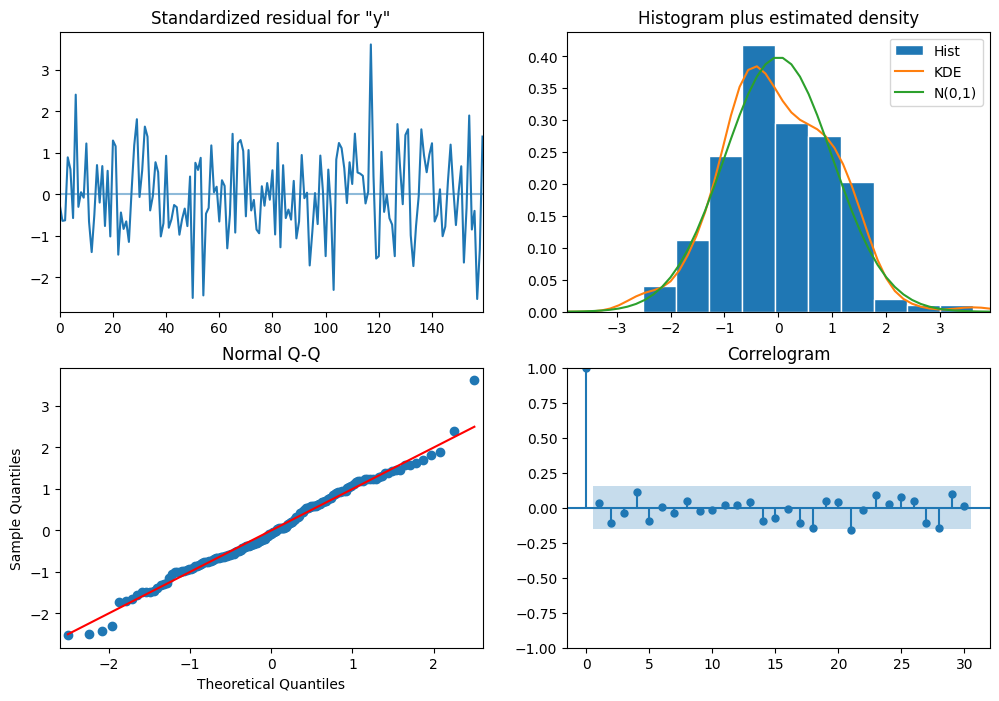

In [235]:
model_arma11.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

Hasil

Ljung-Box → p-value > 0,05 ✅

Jarque-Bera → p-value > 0,05 ✅

ARCH → p-value > 0,05 ✅

**d. Overfitting**

In [236]:
# Model ARMA(2,1)
model_arma21 = ARIMA(
    train_arma11,
    order=(2,0,1)
).fit()

print(model_arma21.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -214.092
Date:                Wed, 23 Sep 2026   AIC                            438.184
Time:                        04:57:41   BIC                            453.560
Sample:                             0   HQIC                           444.428
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0688      0.154     -0.447      0.655      -0.370       0.233
ar.L1          0.3861      0.118      3.284      0.001       0.156       0.617
ar.L2         -0.1806      0.107     -1.694      0.0

In [237]:
# Model ARMA(1,2)
model_arma12 = ARIMA(
    train_arma11,
    order=(1,0,2)
).fit()

print(model_arma12.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -212.045
Date:                Wed, 23 Sep 2026   AIC                            434.090
Time:                        04:57:43   BIC                            449.466
Sample:                             0   HQIC                           440.334
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0711      0.167     -0.424      0.671      -0.399       0.257
ar.L1         -0.3625      0.186     -1.954      0.051      -0.726       0.001
ma.L1          1.4562      0.138     10.525      0.0

In [238]:
pd.DataFrame({
    'Model': [
        'ARMA(1,1)',
        'ARMA(2,1)',
        'ARMA(1,2)'
    ],

    'AIC': [
        model_arma11.aic,
        model_arma21.aic,
        model_arma12.aic
    ],

    'BIC': [
        model_arma11.bic,
        model_arma21.bic,
        model_arma12.bic
    ]
})

,Model,AIC,BIC
0,"ARMA(1,1)",439.467364,451.768060
1,"ARMA(2,1)",438.184008,453.559877
2,"ARMA(1,2)",434.090349,449.466218


Hasil overfitting menunjukkan bahwa model ARMA(2,1) memiliki AIC yang sedikit lebih kecil dibandingkan ARMA(1,1), tetapi nilai BIC lebih besar dan parameter AR pada lag kedua tidak signifikan, sehingga model ARMA(2,1) tidak dipilih. Model ARMA(1,2) menghasilkan nilai AIC dan BIC paling kecil, yaitu masing-masing 434,090 dan 449,466. Parameter MA(1) dan MA(2) signifikan, sedangkan parameter AR(1) memiliki p-value 0,051 yang sangat dekat dengan taraf nyata 5%. Maka dari itu untuk ARMA(1,2) akan diuji diagnostik residualnya

## Uji Diagnostik Residual ARMA(1,2)

In [239]:
residual_arma12 = model_arma12.resid
residual_arma12

array([-0.34714636, -0.68390576, -0.64415705,  0.81944265,  0.43172364,
       -0.4604075 ,  2.38206572, -0.546305  ,  0.33077938,  0.06791286,
        0.81968927, -0.28565994, -1.50378531, -0.0594494 ,  0.19122728,
       -0.05248604,  0.61659772, -0.73164551,  0.62175903, -0.98850123,
        1.19323768,  1.10716835, -1.59871649,  0.22305932, -1.25710696,
       -0.41914525, -1.09421494, -0.09900249,  1.1996474 ,  1.33434807,
        0.21900637,  0.55776933,  1.62436057,  1.10441441, -0.11780606,
        0.07152423,  0.72326939,  0.39813718, -0.82319332, -0.54664671,
        0.81602333, -0.93376161, -0.34393182, -0.27636424, -0.45109021,
       -0.73875762, -0.69487315, -0.25093998, -0.87078987,  0.49830633,
       -2.479757  ,  0.90237901,  0.34052307,  0.55703059, -1.78178252,
       -0.68459357, -0.04292363,  0.5510508 ,  0.42364515, -0.11896293,
       -0.26610596,  0.1116711 ,  0.29261999, -1.32690685, -0.22041742,
        1.16860973, -1.03053987,  1.45858689,  0.99474542,  0.91

In [240]:
# Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residual_arma12,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

# Uji Jarque Bera
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(
    residual_arma12[1:]
)

print("=== Uji Jarque-Bera ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skew:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

# Uji Heteroskedastisitas
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residual_arma12)

print("=== Uji ARCH ===")
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"LM p-value   : {arch_test[1]:.4f}")
print(f"F Statistic  : {arch_test[2]:.4f}")
print(f"F p-value    : {arch_test[3]:.4f}")

      lb_stat  lb_pvalue
10   0.820921   0.999931
20  10.840640   0.950251
=== Uji Jarque-Bera ===
JB Statistic : 0.7851
p-value      : 0.6753
Skewness     : 0.0843
Kurtosis     : 3.3002
=== Uji ARCH ===
LM Statistic : 6.8990
LM p-value   : 0.7349
F Statistic  : 0.6701
F p-value    : 0.7506


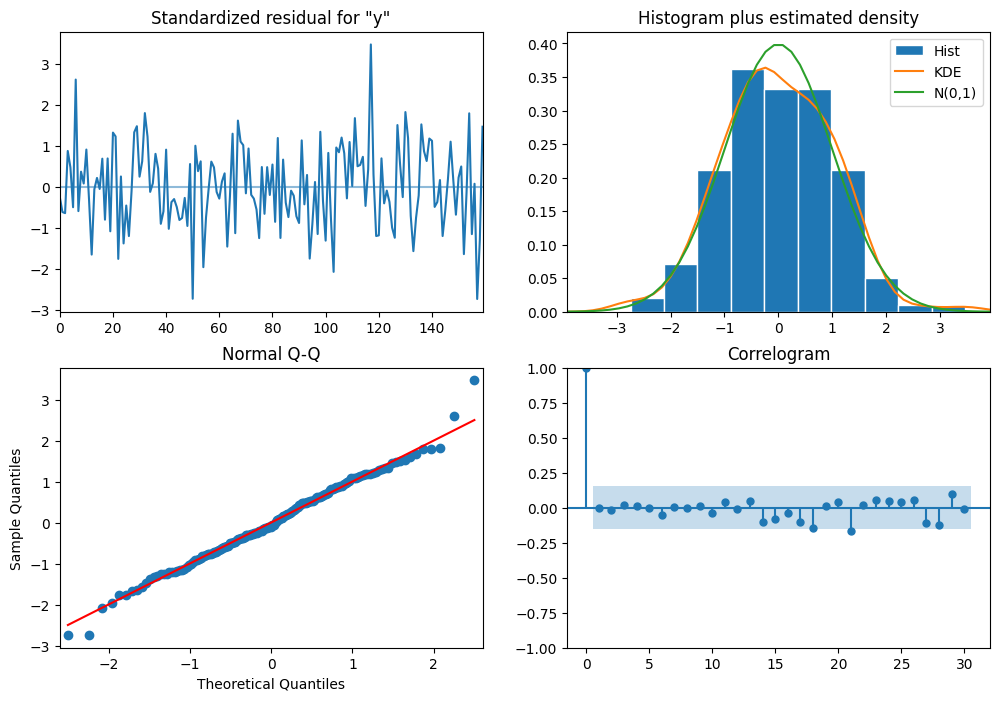

In [241]:
model_arma12.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

Berdasarkan hasil overfitting, model ARMA(1,2) memiliki nilai AIC sebesar 434,090 dan BIC sebesar 449,466, yang lebih kecil dibandingkan model ARMA(1,1) dengan AIC sebesar 439,467 dan BIC sebesar 451,768. Pada model ARMA(1,2), parameter MA(1) dan MA(2) signifikan, sedangkan parameter AR(1) memiliki p-value sebesar 0,051 yang sangat dekat dengan taraf nyata 5%. Hasil diagnostik sisaan menunjukkan p-value Ljung-Box pada lag 10 dan 20 masing-masing sebesar 0,9999 dan 0,9503, sehingga tidak terdapat autokorelasi sisaan. Uji Jarque-Bera menghasilkan p-value sebesar 0,6753 sehingga asumsi normalitas tidak ditolak, sedangkan uji ARCH menghasilkan p-value sebesar 0,7349 sehingga tidak terdapat indikasi heteroskedastisitas. Berdasarkan nilai AIC dan BIC serta diagnostik sisaan, ARMA(1,2) dipilih sebagai model terbaik.

### 5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

**a. Peramalan**

In [242]:
prediksi_test_arma12 = model_arma12.get_forecast(
    test_arma11.shape[0]
).summary_frame(alpha=0.05)

prediksi_test_arma12

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1.327799,0.906132,-0.448187,3.103785
1,0.276019,1.342821,-2.355862,2.907900
2,-0.196890,1.361656,-2.865687,2.471907
3,-0.025454,1.364112,-2.699065,2.648157
4,-0.087602,1.364435,-2.761845,2.586641
5,-0.065073,1.364477,-2.739398,2.609253
6,-0.073240,1.364483,-2.747576,2.601097
7,-0.070279,1.364483,-2.744617,2.604059
8,-0.071352,1.364483,-2.745691,2.602986
9,-0.070963,1.364483,-2.745302,2.603375


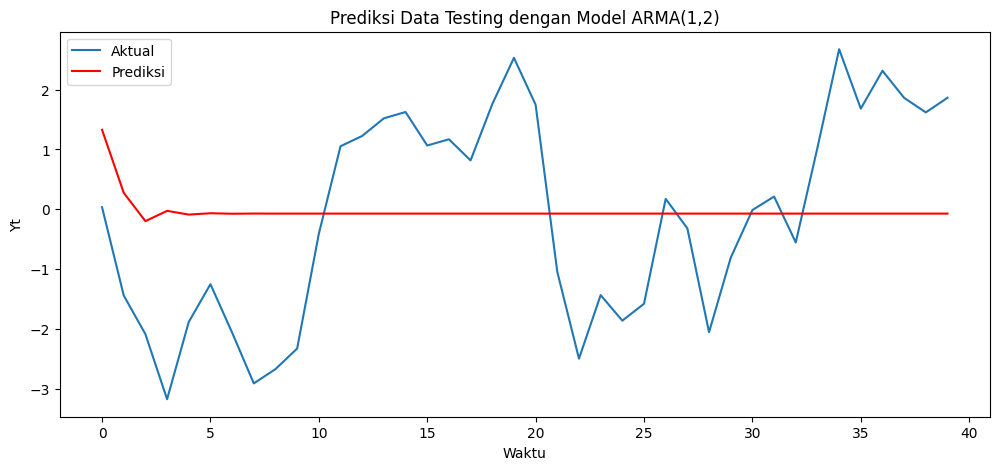

In [243]:
plt.figure(figsize=(12,5))

plt.plot(
    range(len(test_arma11)),
    test_arma11,
    label='Aktual'
)

plt.plot(
    range(len(test_arma11)),
    prediksi_test_arma12['mean'].values,
    color='red',
    label='Prediksi'
)

plt.title('Prediksi Data Testing dengan Model ARMA(1,2)')
plt.xlabel('Waktu')
plt.ylabel('Yt')
plt.legend()
plt.show()

**b. RMSE dan MAPE**

In [244]:
def RMSE(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    return np.sqrt(
        np.mean(
            (actual - predicted)**2
        )
    )


def MAPE(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mask = actual != 0

    return np.mean(
        np.abs(
            (actual[mask] - predicted[mask])
            / actual[mask]
        )
    ) * 100

In [245]:
prediksi_train_arma12 = model_arma12.fittedvalues

In [246]:
# RMSE dan MAPE data training

rmse_train_arma12 = RMSE(
    train_arma11,
    prediksi_train_arma12
)

mape_train_arma12 = MAPE(
    train_arma11,
    prediksi_train_arma12
)


# RMSE dan MAPE data testing

rmse_test_arma12 = RMSE(
    test_arma11,
    prediksi_test_arma12['mean'].values
)

mape_test_arma12 = MAPE(
    test_arma11,
    prediksi_test_arma12['mean'].values
)

In [247]:
evaluasi_arma12 = pd.DataFrame({
    'Data': ['Training', 'Testing'],
    'RMSE': [
        rmse_train_arma12,
        rmse_test_arma12
    ],
    'MAPE (%)': [
        mape_train_arma12,
        mape_test_arma12
    ]
})

evaluasi_arma12

,Data,RMSE,MAPE (%)
0,Training,0.907635,215.129785
1,Testing,1.722755,199.255998
